# Backtesting and Analysis of a Factor-Based Equity Strategy on Indian Market Data


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import yfinance as yf
from datetime import datetime, timedelta
from tqdm import tqdm
from math import sqrt

In [2]:
import warnings
warnings.filterwarnings('ignore')

## Downloading Stock Data

In [3]:
# Function to scrape NIFTY 100 tickers from the NSE India website
def get_nifty100_tickers():
  # Creating a session with browser-like headers to avoid being blocked
  s = requests.Session()
  s.headers.update({"User-Agent": "Mozilla/5.0", "Accept-Language": "en-US,en;q=0.9"})
  s.get("https://www.nseindia.com", timeout=5) # Making initial request to establish session cookies
  response = s.get("https://www.nseindia.com/api/equity-stockIndices?index=NIFTY%20100", timeout=10).json() # Making API request to get the NIFTY 100 data
  return [d["symbol"] + ".NS" for d in response["data"]] # Extracting symbols and appending ".NS" for Yahoo Finance compatibility
TICKERS = get_nifty100_tickers()
print(len(TICKERS))
print(TICKERS)

101
['NIFTY 100.NS', 'SHRIRAMFIN.NS', 'LICI.NS', 'BAJFINANCE.NS', 'ADANIENT.NS', 'TATASTEEL.NS', 'BRITANNIA.NS', 'BAJAJFINSV.NS', 'JINDALSTEL.NS', 'VEDL.NS', 'HDFCLIFE.NS', 'M&M.NS', 'BPCL.NS', 'ICICIBANK.NS', 'SBILIFE.NS', 'HINDZINC.NS', 'SOLARINDS.NS', 'PNB.NS', 'MAZDOCK.NS', 'BEL.NS', 'ENRIN.NS', 'NAUKRI.NS', 'EICHERMOT.NS', 'CANBK.NS', 'IRFC.NS', 'GAIL.NS', 'BANKBARODA.NS', 'CHOLAFIN.NS', 'MAXHEALTH.NS', 'GRASIM.NS', 'ZYDUSLIFE.NS', 'UNITDSPR.NS', 'ADANIPORTS.NS', 'HAL.NS', 'ICICIGI.NS', 'TORNTPHARM.NS', 'INFY.NS', 'COALINDIA.NS', 'NTPC.NS', 'TVSMOTOR.NS', 'RECLTD.NS', 'TATAPOWER.NS', 'POWERGRID.NS', 'CIPLA.NS', 'HAVELLS.NS', 'JIOFIN.NS', 'JSWSTEEL.NS', 'SUNPHARMA.NS', 'ONGC.NS', 'ASIANPAINT.NS', 'MOTHERSON.NS', 'KOTAKBANK.NS', 'IOC.NS', 'CGPOWER.NS', 'PIDILITIND.NS', 'HINDALCO.NS', 'MARUTI.NS', 'JSWENERGY.NS', 'DRREDDY.NS', 'ETERNAL.NS', 'AMBUJACEM.NS', 'BAJAJHFL.NS', 'DLF.NS', 'LT.NS', 'HINDUNILVR.NS', 'HDFCBANK.NS', 'BAJAJ-AUTO.NS', 'VBL.NS', 'ADANIGREEN.NS', 'TITAN.NS', 'SHREEC

### Cleaning the list
The scrape includes the index itself ('NIFTY 100.NS'). We must remove it to keep only the 100 stocks.

In [4]:
TICKERS = [t for t in TICKERS if not t.startswith("NIFTY") and not t.startswith("^")]
print("Cleaned ticker count:", len(TICKERS))

Cleaned ticker count: 100


In [5]:
START_DATE = "2022-01-02"
END_DATE = datetime.today().strftime("%Y-%m-%d")
# Downloading OHLCV data for all 100 tickers (from yfinance)
ohlcv_data = yf.download(TICKERS, start=START_DATE, end=END_DATE, progress=True)

[*********************100%***********************]  100 of 100 completed


In [6]:
ohlcv_data.tail()

Price        Close                                                         \
Ticker      ABB.NS ADANIENSOL.NS  ADANIENT.NS ADANIGREEN.NS ADANIPORTS.NS   
Date                                                                        
2025-11-03  5256.0    994.549988  2467.000000   1105.199951   1444.699951   
2025-11-04  5244.0    985.900024  2419.800049   1086.400024   1444.400024   
2025-11-05  5244.0           NaN  2419.800049   1086.400024           NaN   
2025-11-06  5228.0    968.150024  2314.300049   1060.500000   1436.800049   
2025-11-07  5016.5    960.599976  2369.399902   1059.800049   1448.300049   

Price                                                              \
Ticker     ADANIPOWER.NS AMBUJACEM.NS APOLLOHOSP.NS ASIANPAINT.NS   
Date                                                                
2025-11-03    156.729996   577.200012        7824.5   2512.199951   
2025-11-04    158.389999   567.400024        7810.5   2486.699951   
2025-11-05    158.389999   567.400024        7810.5   2486.699951   
2025-11-06    153.169998   558.400024        7782.0   2602.899902   
2025-11-07    151.479996   558.799988        7642.0   2613.800049   

Price                    ...     Volume                                     \
Ticker      AXISBANK.NS  ...    TMPV.NS TORNTPHARM.NS TRENT.NS TVSMOTOR.NS   
Date                     ...                                                 
2025-11-03  1233.699951  ...  8952229.0      160187.0   292566    932956.0   
2025-11-04  1226.599976  ...  8889004.0      195438.0   475909   3540359.0   
2025-11-05  1226.599976  ...        NaN           NaN        0         NaN   
2025-11-06  1228.500000  ...  6862359.0      173609.0   476465    972150.0   
2025-11-07  1222.800049  ...  6930046.0       94430.0   543059   1074925.0   

Price                                                                          
Ticker     ULTRACEMCO.NS UNITDSPR.NS   VBL.NS   VEDL.NS WIPRO.NS ZYDUSLIFE.NS  
Date                                                                           
2025-11-03         98394   1297031.0  4702192  16492217  4902693       534425  
2025-11-04        199364    961290.0  3554888   9015840  6848284       444915  
2025-11-05             0         NaN        0         0        0            0  
2025-11-06        189652   1003182.0  4827230   7236023  7141517      2919859  
2025-11-07        148161    507698.0  4991085   9229050  5520619       667543  

[5 rows x 500 columns]

### Converting `ohlcv_data` to `data`
Selecting only the 'Close' price from the Dataframe (ohlcv_data)

In [7]:
data=ohlcv_data['Close']

In [8]:
print(f"Shape of data: {data.shape}")
print(data.tail())
print(f"Total Missing Values: {data.isnull().sum()}")

Shape of data: (952, 100)
Ticker      ABB.NS  ADANIENSOL.NS  ADANIENT.NS  ADANIGREEN.NS  ADANIPORTS.NS  \
Date                                                                           
2025-11-03  5256.0     994.549988  2467.000000    1105.199951    1444.699951   
2025-11-04  5244.0     985.900024  2419.800049    1086.400024    1444.400024   
2025-11-05  5244.0            NaN  2419.800049    1086.400024            NaN   
2025-11-06  5228.0     968.150024  2314.300049    1060.500000    1436.800049   
2025-11-07  5016.5     960.599976  2369.399902    1059.800049    1448.300049   

Ticker      ADANIPOWER.NS  AMBUJACEM.NS  APOLLOHOSP.NS  ASIANPAINT.NS  \
Date                                                                    
2025-11-03     156.729996    577.200012         7824.5    2512.199951   
2025-11-04     158.389999    567.400024         7810.5    2486.699951   
2025-11-05     158.389999    567.400024         7810.5    2486.699951   
2025-11-06     153.169998    558.400024         

## Data Preparation & Cleaning

### Handling Missing Data
- ffill(): Forward-fill. Fills a NaN with the last known value. Good for holidays.
- bfill(): Backward-fill. Fills initial NaNs (e.g., from late listings) with the first available price.

In [9]:
data = data.fillna(method='ffill').fillna(method='bfill')

### Resampling to Monthly
The strategy rebalances monthly, so we only need month-end prices.

In [10]:
monthly_prices = data.resample('M').last() #selects the last trading day of each month
print("Monthly data shape:", monthly_prices.shape)
monthly_prices.head()

Monthly data shape: (47, 100)


Ticker,ABB.NS,ADANIENSOL.NS,ADANIENT.NS,ADANIGREEN.NS,ADANIPORTS.NS,ADANIPOWER.NS,AMBUJACEM.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,...,TMPV.NS,TORNTPHARM.NS,TRENT.NS,TVSMOTOR.NS,ULTRACEMCO.NS,UNITDSPR.NS,VBL.NS,VEDL.NS,WIPRO.NS,ZYDUSLIFE.NS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-31,2259.319580,818.099976,1711.799194,1877.849976,700.196045,21.250000,353.109894,4408.351074,3040.497803,769.835693,...,390.850006,1269.189453,1026.751587,594.780029,7055.734375,1156.591187,119.541893,173.269760,271.783142,394.367432
2022-02-28,2120.287598,818.099976,1641.428833,1843.400024,691.593994,24.750000,303.888245,4750.002930,3062.103760,739.313049,...,390.850006,1318.768677,1103.585205,605.865356,6421.672363,1156.591187,124.912262,204.800339,263.809143,349.643341
2022-03-31,2118.814697,818.099976,2011.048584,1914.699951,756.794434,37.020000,295.538879,4466.455566,2970.761230,757.985168,...,390.850006,1338.934814,1270.303223,617.565430,6455.306641,1156.591187,124.357399,224.879242,280.943878,338.098541
2022-04-30,2063.668213,818.099976,2327.715576,2882.800049,837.146423,56.070000,367.584198,4405.383789,3122.436035,725.570435,...,390.850006,1349.677002,1223.395142,646.388062,6482.634277,1156.591187,143.150360,227.666885,243.511154,341.591064
2022-05-31,2389.181641,818.099976,2163.567871,1888.949951,723.216675,64.650002,364.818939,3935.556152,2758.270996,682.351013,...,390.850006,1358.429199,1120.659424,727.032410,5947.177734,1156.591187,139.576736,193.991776,228.794235,367.057617


## Factors

As required, I have selected two common equity factors: **Momentum** and **Value**.

### Calculating the momentum factor
12-month return, skipping last month

In [11]:
momentum = monthly_prices.pct_change(12).shift(1)
momentum.tail()

Ticker,ABB.NS,ADANIENSOL.NS,ADANIENT.NS,ADANIGREEN.NS,ADANIPORTS.NS,ADANIPOWER.NS,AMBUJACEM.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,...,TMPV.NS,TORNTPHARM.NS,TRENT.NS,TVSMOTOR.NS,ULTRACEMCO.NS,UNITDSPR.NS,VBL.NS,VEDL.NS,WIPRO.NS,ZYDUSLIFE.NS
Date,,,,,,,,,,,,,,,,,,,,,
2025-07-31,-0.278531,-0.115907,-0.175129,-0.426655,-0.014102,-0.184873,-0.135302,0.174223,-0.188650,-0.051472,...,0.000000,0.232873,0.135594,0.239022,0.042580,0.126275,-0.296101,0.107581,0.053764,-0.075917
2025-08-31,-0.297042,-0.289662,-0.232680,-0.466923,-0.121103,-0.199265,-0.125127,0.136781,-0.214657,-0.083000,...,0.000000,0.191223,-0.139862,0.111584,0.036968,-0.049071,-0.169473,0.030359,-0.010671,-0.213511
2025-09-30,-0.365033,-0.241463,-0.256182,-0.503033,-0.109800,-0.049680,-0.083929,0.101482,-0.185687,-0.109897,...,0.000000,0.031345,-0.259286,0.169512,0.125485,-0.102953,-0.186256,0.006810,-0.036518,-0.120234
2025-10-31,-0.351346,-0.136087,-0.200478,-0.460320,-0.026151,0.102263,-0.095666,0.031924,-0.286370,-0.080858,...,0.000000,0.071150,-0.381945,0.215895,0.042151,-0.159709,-0.266096,-0.025518,-0.080512,-0.070565
2025-11-30,-0.291751,0.010244,-0.157768,-0.286742,0.060040,0.331618,-0.022531,0.096688,-0.135350,0.064080,...,0.048996,0.122413,-0.340890,0.412860,0.086491,-0.003504,-0.212062,0.140674,-0.092859,-0.015618


### Calculating the value factor
Price / 12-Month Moving Average

We take the last available value and forward-fill it for the backtest

In [12]:
# Calculating the value factor
# Price / 12-Month Moving Average
value_ts = monthly_prices / monthly_prices.rolling(12).mean()

# We forward-fill NaNs that occur from the initial 12-month rolling window
value = value_ts.ffill()
value.tail()

Ticker,ABB.NS,ADANIENSOL.NS,ADANIENT.NS,ADANIGREEN.NS,ADANIPORTS.NS,ADANIPOWER.NS,AMBUJACEM.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,...,TMPV.NS,TORNTPHARM.NS,TRENT.NS,TVSMOTOR.NS,ULTRACEMCO.NS,UNITDSPR.NS,VBL.NS,VEDL.NS,WIPRO.NS,ZYDUSLIFE.NS
Date,,,,,,,,,,,,,,,,,,,,,
2025-07-31,0.860573,0.935630,0.951597,0.823460,1.063740,1.050757,1.068439,1.080248,0.953823,0.949280,...,1.000000,1.131938,0.816956,1.079247,1.078178,0.913923,0.958041,0.970942,0.937334,1.009711
2025-08-31,0.812713,0.905664,0.901518,0.816533,1.027770,1.078221,1.023191,1.088612,1.022059,0.937625,...,1.000000,1.073924,0.884804,1.243187,1.101211,0.907183,0.909415,0.994329,0.944333,1.033445
2025-09-30,0.875995,1.048005,1.028040,0.981911,1.101485,1.285397,1.044993,1.056971,0.985054,1.022744,...,1.000000,1.080515,0.813919,1.279980,1.060987,0.929883,0.849564,1.103707,0.912352,1.041154
2025-10-31,0.909748,1.183730,1.034258,1.131429,1.133064,1.363018,1.038719,1.087024,1.067107,1.108013,...,1.044730,1.057331,0.846649,1.265779,1.030027,1.005381,0.917761,1.155571,0.924542,1.034668
2025-11-30,0.905117,1.139316,0.990919,1.075321,1.111477,1.270956,1.022019,1.071002,1.104745,1.091872,...,1.030524,1.055722,0.862598,1.209516,1.016339,1.008881,0.941721,1.184599,0.920668,1.003411


## Portfolio Construction

In [13]:
#Function to create long-short portfolios
def make_long_short(factor_df, price_df, top_pct=0.2):
    rets = price_df.pct_change().shift(-1) #future 1-month returns for all stocks
    longs, shorts = [], []
    #excluding the last row, which has no future
    for date in factor_df.index[:-1]:
        scores = factor_df.loc[date].dropna() #factor scores for the current date, dropping any stocks with no score
        n = len(scores)
        k = max(1, int(n * top_pct)) #no. of stocks for the top/bottom quintile (20%)
        ranked = scores.sort_values(ascending=False)
        long_list, short_list = ranked.index[:k], ranked.index[-k:] #ticker lists for long (top k) and short (bottom k)
        next_ret = rets.loc[date] #next month's returns
        longs.append(next_ret[long_list].mean()) #equal-weighted returns
        shorts.append(next_ret[short_list].mean())
    idx = factor_df.index[:-1]
    return pd.Series(longs, index=idx), pd.Series(shorts, index=idx)

mom_long, mom_short = make_long_short(momentum, monthly_prices)
val_long, val_short = make_long_short(value, monthly_prices)
mom_ls = mom_long - mom_short
val_ls = val_long - val_short

In [14]:
#Performance metric functions

#Compound Annual Growth Rate (CAGR)
def cagr(returns):
    total = (1 + returns).prod()
    years = len(returns) / 12
    return total**(1/years) - 1

#Annualized Sharpe Ratio
def sharpe(returns):
    return (returns.mean() / returns.std()) * np.sqrt(12) #(Mean monthly return / StdDev of monthly return) * sqrt(12) to annualize

#Maximum Drawdown
def max_dd(returns):
    cum = (1 + returns).cumprod() #cumulative return series
    peak = cum.cummax() #running maximum (peak)
    dd = (cum - peak) / peak #drawdown -> (trough - peak) / peak
    return dd.min() #most severe drawdown

#Dataframe to display the metrics
metrics = pd.DataFrame({
    "CAGR": [cagr(mom_ls), cagr(val_ls)],
    "Sharpe": [sharpe(mom_ls), sharpe(val_ls)],
    "Max Drawdown": [max_dd(mom_ls), max_dd(val_ls)]
}, index=["Momentum", "Value"])
metrics

,CAGR,Sharpe,Max Drawdown
Momentum,0.045090,0.517188,-0.275938
Value,0.063191,0.572792,-0.204341


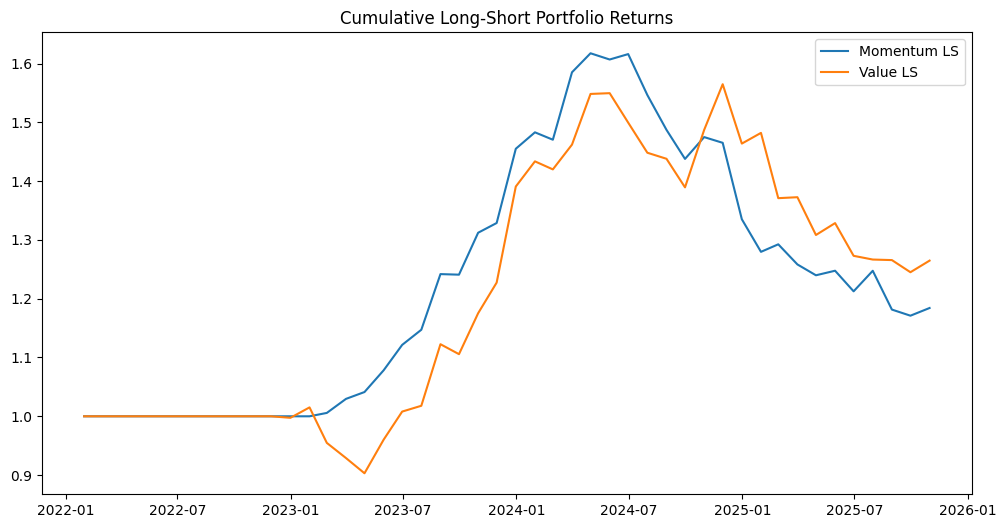

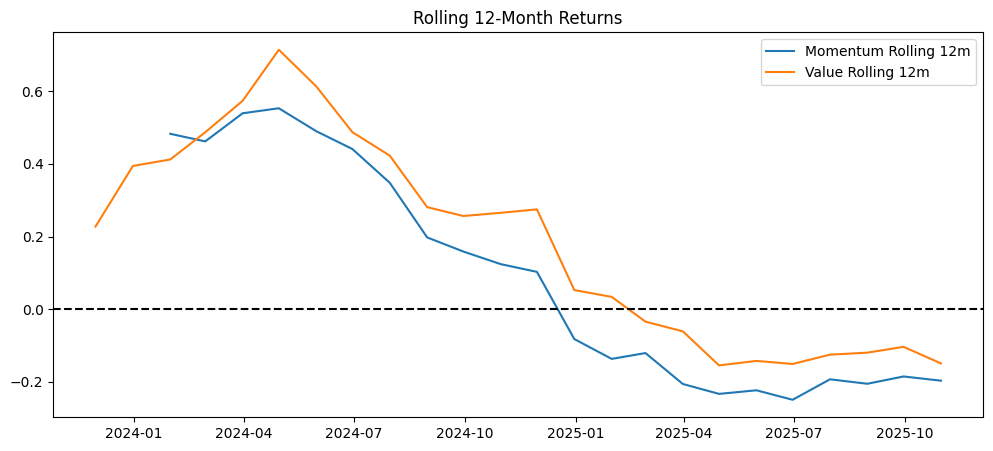

In [15]:
#Plotting cumulative (compounded) returns of the two strategies
plt.figure(figsize=(12,6))
plt.plot((1+mom_ls.fillna(0)).cumprod(), label='Momentum LS')
plt.plot((1+val_ls.fillna(0)).cumprod(), label='Value LS')
plt.legend()
plt.title("Cumulative Long-Short Portfolio Returns")
plt.show()

# Plotting the 12-month rolling returns
plt.figure(figsize=(12,5))
plt.plot(mom_ls.rolling(12).apply(lambda x: (1+x).prod()-1), label='Momentum Rolling 12m')
plt.plot(val_ls.rolling(12).apply(lambda x: (1+x).prod()-1), label='Value Rolling 12m')
plt.axhline(0, color='k', linestyle='--')
plt.legend()
plt.title("Rolling 12-Month Returns")
plt.show()

**Plot Analysis:**

- Cumulative Returns: The first chart shows what $1 invested at the start would have grown to. Both strategies were clearly profitable. The Value strategy (orange) tracks the Momentum strategy (blue) very closely and ends slightly higher, confirming its better CAGR.

- Rolling 12-Month Returns: The second chart shows the performance over the previous 12 months at any given point. It shows both strategies had a strong, positive period in 2023-2024. Both have recently turned negative, which aligns with the downturn seen in the cumulative plot.

## Backtesting & Analysis: NIFTY 50 Benchmark

In [16]:
nifty = yf.download("^NSEI", start=START_DATE, end=END_DATE, progress=False)['Close'].resample('M').last() #NIFTY 50 (benchmark) data
nifty_ret = nifty.pct_change().dropna() #NIFTY 50 monthly returns

print("Benchmark Metrics")
print("NIFTY50 CAGR:", cagr(nifty_ret))
print("NIFTY50 Sharpe:", sharpe(nifty_ret))
print("NIFTY50 MaxDD:", max_dd(nifty_ret))

Benchmark Metrics
NIFTY50 CAGR: Ticker
^NSEI    0.105758
dtype: float64
NIFTY50 Sharpe: Ticker
^NSEI    0.861113
dtype: float64
NIFTY50 MaxDD: Ticker
^NSEI   -0.142814
dtype: float64


### Factor Portfolios vs. NIFTY 50

In [17]:
#Calculating cumulative returns for all three

mom_ls_aligned = mom_ls
mom_ls_aligned.index = nifty_ret.index

val_ls_aligned = val_ls
val_ls_aligned.index = nifty_ret.index

mom_cumulative = (1 + mom_ls_aligned.fillna(0)).cumprod()
val_cumulative = (1 + val_ls_aligned.fillna(0)).cumprod()
nifty_cumulative = (1 + nifty_ret.fillna(0)).cumprod()

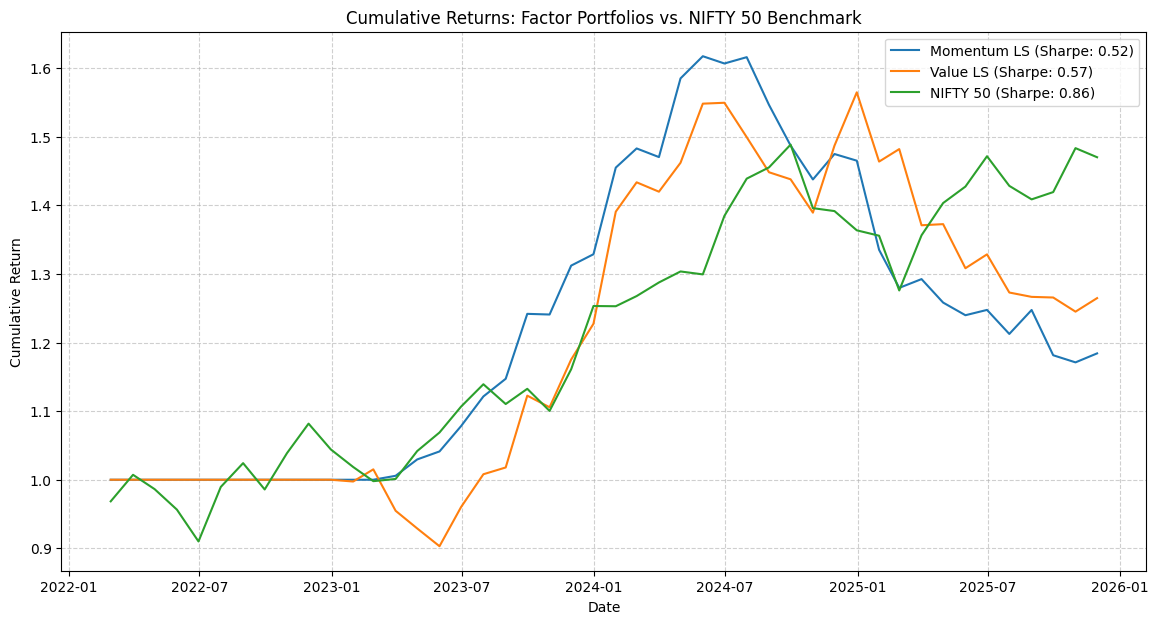

In [18]:
# Plotting all three on the same chart
plt.figure(figsize=(14, 7))
plt.plot(mom_cumulative, label=f'Momentum LS (Sharpe: {sharpe(mom_ls):.2f})')
plt.plot(val_cumulative, label=f'Value LS (Sharpe: {sharpe(val_ls):.2f})')
plt.plot(nifty_cumulative, label=f'NIFTY 50 (Sharpe: {sharpe(nifty_ret).iloc[0]:.2f})')

plt.title('Cumulative Returns: Factor Portfolios vs. NIFTY 50 Benchmark')
plt.ylabel('Cumulative Return')
plt.xlabel('Date')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Plot Analysis:** Factor Portfolios vs. NIFTY 50

This plot  compares the long-short strategies to the "buy-and-hold" NIFTY 50 benchmark.

- NIFTY 50 (Green): Was the best-performing asset, with a strong, steady climb and the highest Sharpe Ratio (0.86).
- Momentum (Blue) & Value (Orange): Both market-neutral strategies managed to generate positive returns and tracked each other closely. However, they were much more volatile and ultimately underperformed the simple buy-and-hold benchmark on both an absolute and risk-adjusted basis.

## Blended Multi-Factor Score
Here, I will combine the two factors by:

- Calculating the Z-Score (standardizing) for each factor monthly.

- Averaging the two Z-Scores to get a single "blend" score.

- Backtesting this new blended factor.

In [19]:
# monthly cross-sectional Z-scores ((value - mean) / std_dev)
mom_z = momentum.apply(lambda r: (r - r.mean()) / r.std(), axis=1)
val_z = value.apply(lambda r: (r - r.mean()) / r.std(), axis=1)

# blended factor obtained by averaging the Z-scores
blend = (mom_z + val_z) / 2

# Run the backtest on the blended factor
blend_long, blend_short = make_long_short(blend, monthly_prices)
blend_ls = blend_long - blend_short

# metrics for the blended strategy
print("Blend CAGR:", cagr(blend_ls))
print("Blend Sharpe:", sharpe(blend_ls))
print("Blend MaxDD:", max_dd(blend_ls))

Blend CAGR: 0.051773341329670375
Blend Sharpe: 0.5255547587089511
Blend MaxDD: -0.24807055876460804
